# MES MACD mean-reversion, 15-minute bars (Tradovate exchange)

A third mean-reversion construction, after VWAP deviation-band (decisively
negative) and Bollinger Band (this program's strongest walk-forward-
confirmed result, MES/MNQ 30m). This one fades an extreme MACD histogram
reading instead of an extreme price level -- the histogram (MACD line minus
its own signal line) isn't naturally bounded the way a price-vs-band
distance is, so "extreme" is defined relative to the histogram's own rolling
mean/std (a z-score band), not a fixed threshold.

**Mechanism** (`MacdMeanReversionStrategy`): enters short when the histogram
reaches or exceeds `rolling_mean + entry_std * rolling_std` (unusually
strong bullish momentum -- expecting reversion down), long at the symmetric
lower band (unusually strong bearish momentum -- expecting reversion up),
filled at that bar's close (the histogram is only known at bar close, not an
intrabar-touchable price level). Fixed fractional-distance stop-loss/
take-profit, same convention as `BollingerMeanReversionStrategy`.

**Also testing KAMA as the underlying moving average** (`Indicators.macd_
kama`, new): Kaufman's Adaptive Moving Average tracks fast during clean
trends and flattens during chop, so a KAMA-based MACD should react
differently (likely less whipsaw-prone) than the standard EMA-based one --
included as a first-class grid dimension (`ma_type`) rather than assumed to
be better or worse.

**Plan**: Phase 1 grids MACD parameters (several canonical (fast, slow,
signal) triples) x `ma_type` (ema/kama), fixed `entry_std`/placeholder SL-TP.
Phase 2 grids `entry_std` x `sl_percent` on the winner (`tp_percent` fixed).
Then direction comparison, then holdout, then walk-forward if promising --
same escalating-refinement discipline as every other notebook in this
pipeline.


In [1]:
import os
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import HTML, display

from backtester.backtest_runner import Backtester
from backtester.exchange import Exchange, MarginAllocationType, MarketType, TradovateSymbolConfigProvider
from backtester.exchange.event_log import OrderFilled
from backtester.exchange_config import TRADOVATE_FUTURES
from backtester.indicators import Indicators
from backtester.market import Market
from backtester.middleware import MaxDailyLossMiddleware, TradeifyDrawdownMiddleware
from backtester.performance import PerformanceAnalyzer
from backtester.portfolio import Portfolio, WeightedStrategy
from backtester.strategies import MacdMeanReversionStrategy, StrategyDirection
from data_aggregator.databento_aggregator import load_1m_parquet_resampled

cwd = os.getcwd()
print(cwd)


/Users/nick/Documents/www/alphakit/notebooks/pipelines/breakout


In [2]:
def _find_upwards(relative_path: str, start: Path) -> Path:
    for ancestor in [start, *start.parents]:
        candidate = ancestor / relative_path
        if candidate.exists():
            return candidate
    raise FileNotFoundError(
        f"Could not find {relative_path} above {start} -- run "
        "data_aggregator.databento_aggregator to download it first."
    )


DISPLAY_SYMBOL = "MES"
SYMBOL = "MES/USD"
INTERVAL = 15
UNIT_OF_TIME = "minute"

data_path = _find_upwards("apps/backtester/datasets/databento/MES_c_0_1m.parquet", start=Path(cwd))
ohlc = load_1m_parquet_resampled(data_path, interval=INTERVAL, unit_of_time=UNIT_OF_TIME)
print(f"Bars: {len(ohlc)}  span: {ohlc.index[0]} -> {ohlc.index[-1]}")


Bars: 168278  span: 2019-05-05 22:14:59.999000 -> 2026-07-12 23:14:59.999000


## Phase 1: grid MACD parameters x ma_type (ema/kama), direction=both

`entry_std=2.0`, `rolling_lookback=100`, placeholder `sl_percent=0.01`/
`tp_percent=0.01` fixed for this pass -- tuned properly in Phase 2.


In [3]:
MACD_PARAM_CANDIDATES = [(5, 13, 5), (8, 17, 9), (12, 26, 9), (19, 39, 9)]
MA_TYPE_CANDIDATES = ["ema", "kama"]
ROLLING_LOOKBACK = 100
PLACEHOLDER_ENTRY_STD = 2.0
PLACEHOLDER_SL_PERCENT = 0.01
PLACEHOLDER_TP_PERCENT = 0.01
DEPOSIT_USD = 50_000


def run_macd_mr_backtest(ohlc_slice: pd.DataFrame, fast: int, slow: int, signal: int, ma_type: str,
                          entry_std: float, sl_percent: float, tp_percent: float, key: str,
                          direction: StrategyDirection = StrategyDirection.both):
    if ma_type == "ema":
        _line, histogram, _signal = Indicators.macd(ohlc_slice, fast=fast, slow=slow, signal=signal)
    else:
        _line, histogram, _signal = Indicators.macd_kama(ohlc_slice, fast=fast, slow=slow, signal=signal)

    rolling_mean = histogram.rolling(ROLLING_LOOKBACK).mean()
    rolling_std = histogram.rolling(ROLLING_LOOKBACK).std()
    upper = rolling_mean + entry_std * rolling_std
    lower = rolling_mean - entry_std * rolling_std

    market = Market()
    market.add_market(symbol=SYMBOL, df=ohlc_slice)
    market.add_indicator(symbol=SYMBOL, interval=INTERVAL, unit_of_time=UNIT_OF_TIME, indicator_name="macd_hist", df=histogram)
    market.add_indicator(symbol=SYMBOL, interval=INTERVAL, unit_of_time=UNIT_OF_TIME, indicator_name="hist_upper", df=upper)
    market.add_indicator(symbol=SYMBOL, interval=INTERVAL, unit_of_time=UNIT_OF_TIME, indicator_name="hist_lower", df=lower)
    market.compile()

    portfolio = Portfolio(weighted_strategies=[
        WeightedStrategy(weight=1.0, strategy=MacdMeanReversionStrategy(
            key=key, market=market, symbol=SYMBOL, histogram_key="macd_hist", upper_key="hist_upper", lower_key="hist_lower",
            sl_percent=sl_percent, tp_percent=tp_percent, direction=direction,
        )),
    ], output_scale=1)

    symbol_config_provider = TradovateSymbolConfigProvider(symbols=TRADOVATE_FUTURES, default_fee_per_contract=0.0)
    exchange = Exchange(
        market=market, slippage=0.0, maker_fee=0.0, taker_fee=0.0,
        market_type=MarketType.future, max_leverage=10,
        margin_allocation_type=MarginAllocationType.cross,
        symbol_config_provider=symbol_config_provider,
    )
    reporter = PerformanceAnalyzer(market=market, exchange=exchange, portfolio=portfolio,
                                    benchmark_symbols=[SYMBOL], periods_per_year=252)

    market.reset()
    drawdown_middleware = TradeifyDrawdownMiddleware(drawdown_percent=0.5)
    daily_loss_middleware = MaxDailyLossMiddleware(max_loss_percent=0.5)
    backtest = Backtester(market=market, portfolio=portfolio, exchange=exchange, reporter=reporter,
                           middlewares=[daily_loss_middleware, drawdown_middleware])
    backtest.exchange.transactions.add_deposit(asset="USD", volume=DEPOSIT_USD)
    backtest.run_all()
    return backtest, drawdown_middleware


def _summarize(bt, drawdown_mw, **extra_cols):
    summary = bt.reporter.summary["algo"]
    total_fees = sum(e.fees_volume for e in bt.exchange.event_log.get_events() if isinstance(e, OrderFilled))
    row = {**extra_cols}
    row.update({
        "net_return_percent": summary["net_return_percent"], "sharpe_ratio": summary["sharpe_ratio"],
        "max_drawdown_percent": summary["max_drawdown_percent"], "closed_trades": summary["closed_trades"],
        "trades_per_year": round(summary["closed_trades"] / 7.2, 1), "win_rate_percent": summary["win_rate_percent"],
        "profit_factor": summary["profit_factor"], "r_multiple_expectancy": summary["r_multiple_expectancy"],
        "dollar_profit_factor": summary["dollar_profit_factor"], "dollar_expectancy": summary["dollar_expectancy"],
        "total_fees_usd": total_fees, "account_failed": drawdown_mw.account_failed,
    })
    return row


grid1_rows = []
grid1_backtests = {}
_t0 = time.time()
for fast, slow, signal in MACD_PARAM_CANDIDATES:
    for ma_type in MA_TYPE_CANDIDATES:
        bt, drawdown_mw = run_macd_mr_backtest(ohlc, fast, slow, signal, ma_type, PLACEHOLDER_ENTRY_STD,
                                                  PLACEHOLDER_SL_PERCENT, PLACEHOLDER_TP_PERCENT,
                                                  key=f"MACDMR_ind_{fast}_{slow}_{signal}_{ma_type}")
        grid1_backtests[(fast, slow, signal, ma_type)] = (bt, drawdown_mw)
        grid1_rows.append(_summarize(bt, drawdown_mw, macd_params=f"{fast}/{slow}/{signal}",
                                       fast=fast, slow=slow, signal=signal, ma_type=ma_type))
    print(f"macd_params={fast}/{slow}/{signal} done, {time.time() - _t0:.0f}s elapsed", flush=True)

grid1_results = pd.DataFrame(grid1_rows).sort_values("sharpe_ratio", ascending=False).reset_index(drop=True)
print("\nphase 1 grid done in " + f"{time.time() - _t0:.0f}s\n")
print(grid1_results[["macd_params", "ma_type", "net_return_percent", "sharpe_ratio", "max_drawdown_percent",
                       "closed_trades", "win_rate_percent", "dollar_profit_factor", "account_failed"]].to_string())


macd_params=5/13/5 done, 24s elapsed


macd_params=8/17/9 done, 51s elapsed


macd_params=12/26/9 done, 80s elapsed


macd_params=19/39/9 done, 109s elapsed



phase 1 grid done in 109s

  macd_params ma_type  net_return_percent  sharpe_ratio  max_drawdown_percent  closed_trades  win_rate_percent  dollar_profit_factor  account_failed
0     12/26/9     ema          -19.798190     -0.216776              -29.4361         1151.0         49.956560              0.963167           False
1     19/39/9    kama          -21.162360     -0.222310              -26.1648         1222.0         49.836334              0.967725           False
2      5/13/5    kama          -22.957070     -0.230097              -37.4429         1383.0         50.325380              0.969244           False
3     19/39/9     ema          -26.390650     -0.348081              -39.0613         1096.0         48.722628              0.933513           False
4      8/17/9    kama          -30.121315     -0.365045              -41.8397         1324.0         49.622356              0.934222           False
5      8/17/9     ema          -35.098975     -0.500160              -36.0639 

## Phase 2: grid entry_std x sl_percent on the best (macd_params, ma_type) combo

Holding the MACD shape fixed at Phase 1's winner, `tp_percent=0.01` fixed
(matching this pipeline's other mean-reversion winners), grids `entry_std`
(how extreme a histogram reading must be to trigger) x `sl_percent` directly.


In [4]:
best_row = grid1_results.iloc[0]
best_fast, best_slow, best_signal, best_ma_type = int(best_row["fast"]), int(best_row["slow"]), int(best_row["signal"]), best_row["ma_type"]
print(f"Phase 1 winner: fast={best_fast}, slow={best_slow}, signal={best_signal}, ma_type={best_ma_type}")

ENTRY_STD_CANDIDATES = [1.5, 2.0, 2.5, 3.0]
SL_PERCENT_CANDIDATES = [0.005, 0.01, 0.015, 0.02]
FIXED_TP_PERCENT = 0.01

grid2_rows = []
grid2_backtests = {}
_t0 = time.time()
for entry_std in ENTRY_STD_CANDIDATES:
    for sl_percent in SL_PERCENT_CANDIDATES:
        bt, drawdown_mw = run_macd_mr_backtest(ohlc, best_fast, best_slow, best_signal, best_ma_type,
                                                  entry_std, sl_percent, FIXED_TP_PERCENT,
                                                  key=f"MACDMR_band_{entry_std}_{sl_percent}")
        grid2_backtests[(entry_std, sl_percent)] = (bt, drawdown_mw)
        grid2_rows.append(_summarize(bt, drawdown_mw, entry_std=entry_std, sl_percent=sl_percent))
    print(f"entry_std={entry_std} done, {time.time() - _t0:.0f}s elapsed", flush=True)

grid2_results = pd.DataFrame(grid2_rows).sort_values("sharpe_ratio", ascending=False).reset_index(drop=True)
print("\nphase 2 grid done in " + f"{time.time() - _t0:.0f}s\n")
print(grid2_results.to_string())


Phase 1 winner: fast=12, slow=26, signal=9, ma_type=ema


entry_std=1.5 done, 67s elapsed


entry_std=2.0 done, 123s elapsed


entry_std=2.5 done, 161s elapsed


entry_std=3.0 done, 198s elapsed



phase 2 grid done in 198s

    entry_std  sl_percent  net_return_percent  sharpe_ratio  max_drawdown_percent  closed_trades  trades_per_year  win_rate_percent  profit_factor  r_multiple_expectancy  dollar_profit_factor  dollar_expectancy  total_fees_usd  account_failed
0         2.0       0.020           25.397330      0.271686              -25.6928          747.0            103.8         69.076305       1.133475               0.040848              1.071349          21.789391         3240.51           False
1         2.5       0.020           18.780490      0.247682              -19.9985          542.0             75.3         68.819188       1.119725               0.036941              1.079108          21.029843         2022.93           False
2         2.5       0.015           -3.538573     -0.004828              -22.1142          639.0             88.8         60.876369       1.049549               0.019240              1.004805           1.072525         2132.13           False


### Heatmaps: Sharpe ratio and net return across (entry_std, sl_percent)


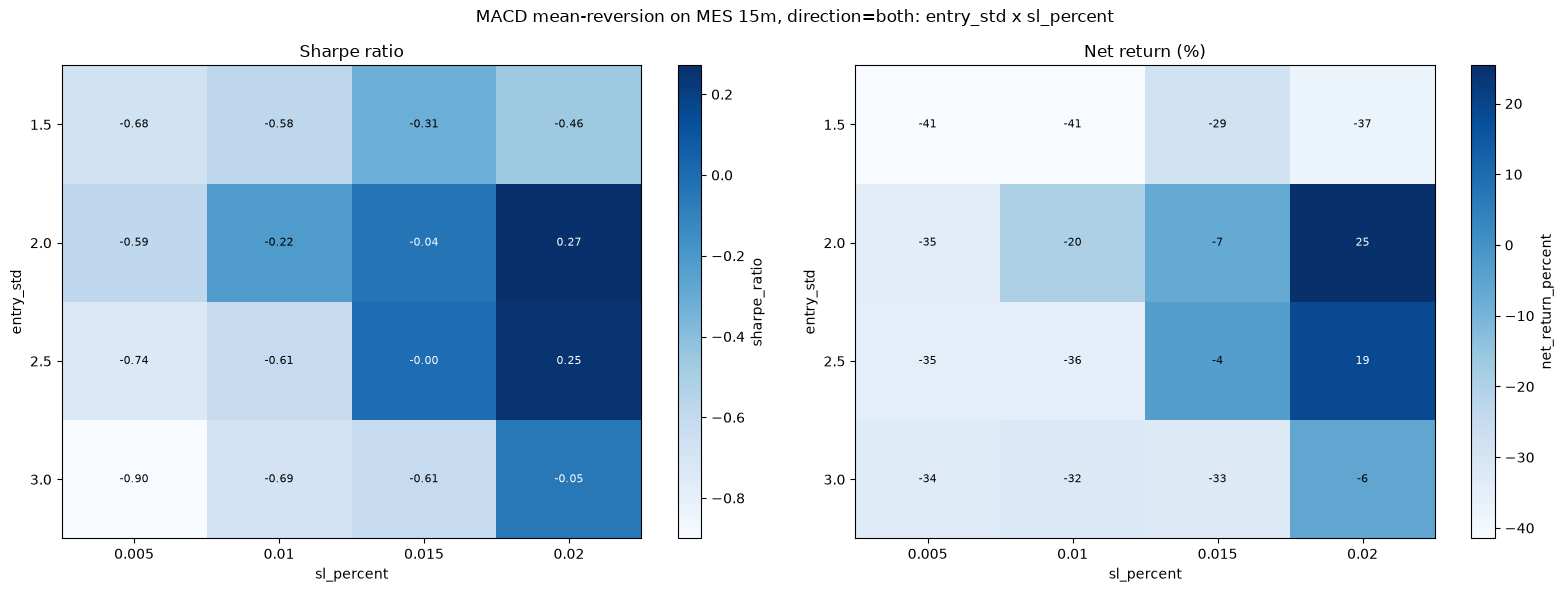

In [5]:
def _plot_heatmap(ax, pivot: pd.DataFrame, title: str, fmt: str, xlabel: str, ylabel: str):
    values = pivot.values.astype(float)
    vmin, vmax = np.nanmin(values), np.nanmax(values)
    span = vmax - vmin if vmax > vmin else 1.0
    im = ax.imshow(values, cmap="Blues", aspect="auto")
    ax.set_xticks(range(len(pivot.columns)), labels=[str(c) for c in pivot.columns])
    ax.set_yticks(range(len(pivot.index)), labels=[str(i) for i in pivot.index])
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    for i in range(values.shape[0]):
        for j in range(values.shape[1]):
            val = values[i, j]
            normalized = (val - vmin) / span
            ax.text(j, i, format(val, fmt), ha="center", va="center", fontsize=8,
                    color="white" if normalized > 0.6 else "black")
    return im


sharpe_pivot = grid2_results.pivot(index="entry_std", columns="sl_percent", values="sharpe_ratio")
return_pivot = grid2_results.pivot(index="entry_std", columns="sl_percent", values="net_return_percent")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
im0 = _plot_heatmap(axes[0], sharpe_pivot, "Sharpe ratio", ".2f", "sl_percent", "entry_std")
fig.colorbar(im0, ax=axes[0], label="sharpe_ratio")
im1 = _plot_heatmap(axes[1], return_pivot, "Net return (%)", ".0f", "sl_percent", "entry_std")
fig.colorbar(im1, ax=axes[1], label="net_return_percent")
fig.suptitle("MACD mean-reversion on MES 15m, direction=both: entry_std x sl_percent")
fig.tight_layout()
plt.show()


## Detailed report for the overall best combo

Full HTML summary (year-by-year split) and equity/drawdown charts for the
best (macd_params, ma_type, entry_std, sl_percent) combo across both grids.


Best combo: 12/26/9 (ema), entry_std=2.0, sl_percent=0.02, tp_percent=0.01
Candles Processed: 168277
Account failed (drawdown breach): False


metric,algo,algo_2019,algo_2020,algo_2021,algo_2022,algo_2023,algo_2024,algo_2025,algo_2026,MES/USD,description
sharpe_ratio,0.2717,-1.0770,1.6461,-1.5039,1.5776,0.3335,0.1919,-1.1685,0.7801,0.6392,"Return per unit of total volatility. <0 bad, ~1 decent, >2 great, >3 excellent."
sortino_ratio,0.3895,-1.3906,2.6259,-2.0051,2.3214,0.4797,0.2633,-1.5082,1.1684,0.9137,"Like Sharpe but only penalizes downside volatility (upside swings aren't ""risk""). >2 good, >3 excellent."
annualized_volatility_percent,9.7433,8.8215,13.1101,8.5737,12.4187,8.6333,7.5358,8.6297,6.5505,16.6830,How much the equity curve swings per year. Lower = smoother.
cagr_percent,3.1969,-13.3485,35.1065,-17.5222,31.4244,3.7084,1.7031,-14.0910,7.3887,14.3689,"Compound annual growth rate, the smoothed annual growth rate. Higher is generally better, but always weigh against volatility/drawdown."
calmar_ratio,0.1244,-1.0251,3.9464,-0.7879,3.4348,0.3154,0.1396,-0.8034,1.6760,0.4057,"CAGR ÷ max drawdown. >1 decent, >3 excellent, <0.5 weak."
recovery_factor,0.9885,-0.6904,3.9464,-0.7860,3.4241,0.3146,0.1396,-0.8013,0.8667,4.5918,Total net profit ÷ max drawdown. >2 solid.
max_drawdown_percent,-25.6928,-13.0216,-8.8959,-22.2378,-9.1488,-11.7561,-12.2028,-17.5400,-4.4084,-35.4168,Largest peak-to-trough loss. Closer to 0 better; below -20% starts getting painful for most investors.
max_drawdown_duration_days,817,232,70,276,138,129,259,359,91,719,How long it took to recover the loss. Shorter is better.
ulcer_index,13.3983,8.8910,2.6181,13.6631,2.9086,4.4458,5.5578,13.9275,1.7886,8.4634,"Combines depth and duration of drawdowns into one number. Lower is better (less ""ulcer-inducing"")."
var_95_percent,-1.0204,-0.8779,-1.2757,-0.9239,-1.2227,-0.9208,-0.8215,-1.0569,-0.6346,-1.4858,"The daily loss you shouldn't exceed on a ""normal"" bad day (worst of the best 95%). Closer to 0 is better."


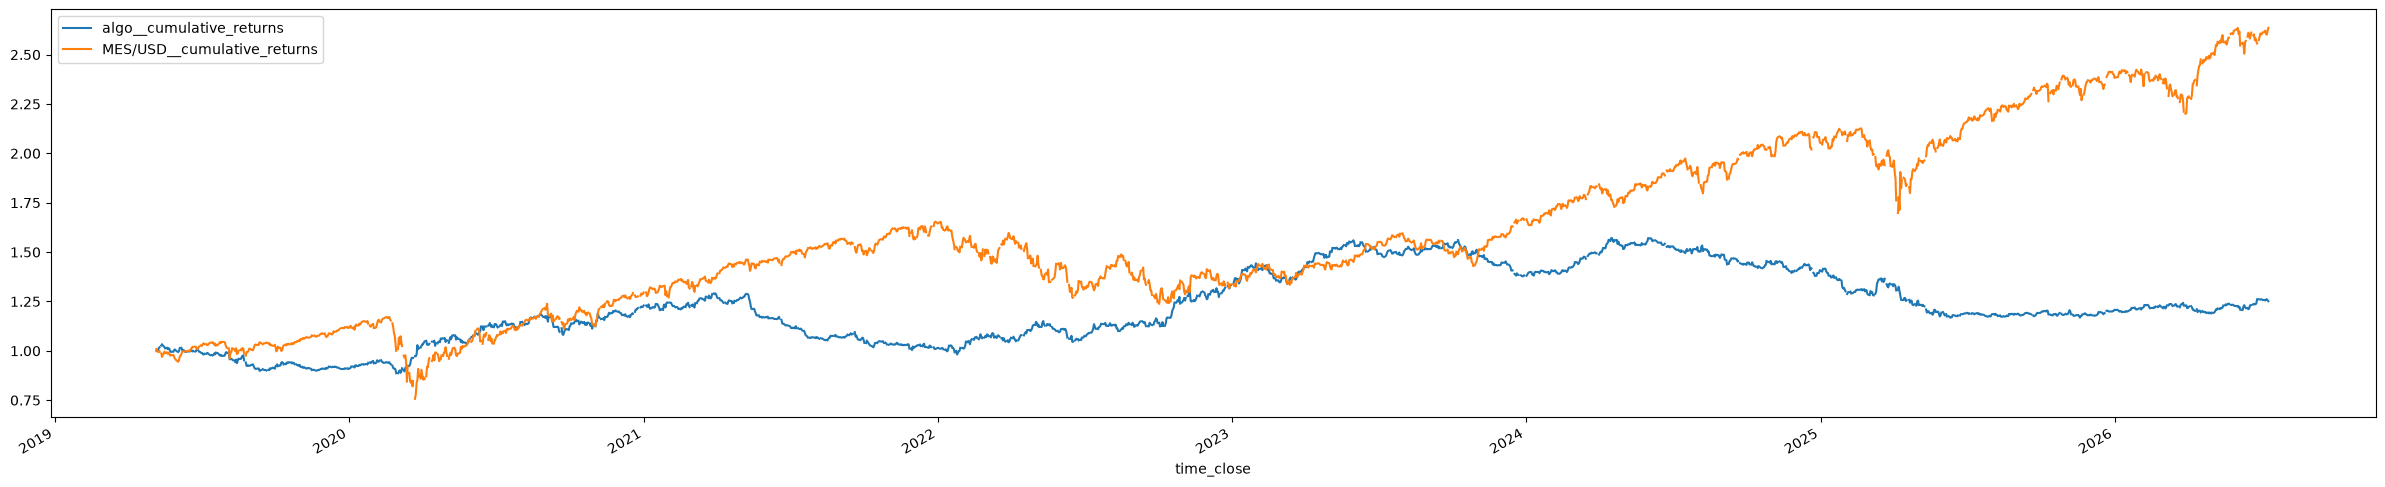

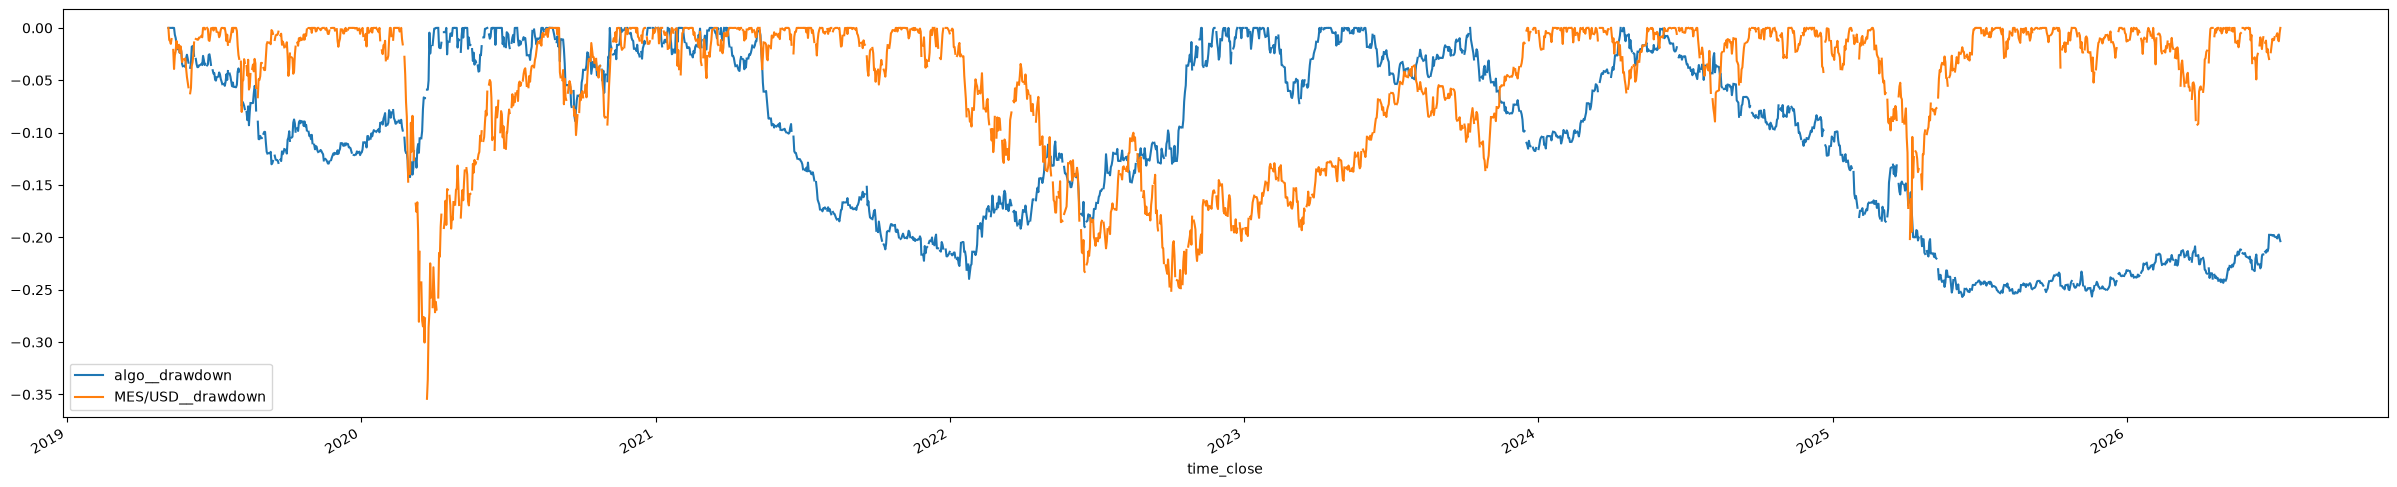

In [6]:
best_entry_std, best_sl_percent = grid2_results.iloc[0][["entry_std", "sl_percent"]]
best_entry_std = float(best_entry_std)
best_sl_percent = float(best_sl_percent)
print(f"Best combo: {best_fast}/{best_slow}/{best_signal} ({best_ma_type}), entry_std={best_entry_std}, sl_percent={best_sl_percent}, tp_percent={FIXED_TP_PERCENT}")
best_backtest, best_drawdown_mw = grid2_backtests[(best_entry_std, best_sl_percent)]

print("Candles Processed:", best_backtest.market.current["num"])
print("Account failed (drawdown breach):", best_drawdown_mw.account_failed)

display(HTML(best_backtest.reporter.summary_html_table(split="Y")))

if best_backtest.reporter.merged is not None:
    best_backtest.reporter.merged.plot(x="time_close", y=[
        "algo__cumulative_returns",
        f"{SYMBOL}__cumulative_returns",
    ], figsize=(30, 6))

    best_backtest.reporter.merged.plot(x="time_close", y=[
        "algo__drawdown",
        f"{SYMBOL}__drawdown",
    ], figsize=(30, 6))


## Direction comparison: both vs. long-only vs. short-only

Holding (macd_params, ma_type, entry_std, sl_percent, tp_percent) fixed at
the overall best combo, re-runs with `direction=long` and `direction=short`.


In [7]:
direction_rows = []
direction_backtests = {}
for direction in [StrategyDirection.both, StrategyDirection.long, StrategyDirection.short]:
    bt, drawdown_mw = run_macd_mr_backtest(ohlc, best_fast, best_slow, best_signal, best_ma_type,
                                              best_entry_std, best_sl_percent, FIXED_TP_PERCENT,
                                              key=f"MACDMR_dir_{direction.value}", direction=direction)
    direction_backtests[direction] = (bt, drawdown_mw)
    direction_rows.append({"direction": direction.value, **_summarize(bt, drawdown_mw)})

direction_df = pd.DataFrame(direction_rows).set_index("direction")
print(direction_df.to_string())


           net_return_percent  sharpe_ratio  max_drawdown_percent  closed_trades  trades_per_year  win_rate_percent  profit_factor  r_multiple_expectancy  dollar_profit_factor  dollar_expectancy  total_fees_usd  account_failed
direction                                                                                                                                                                                                                         
both                25.397330      0.271686              -25.6928          747.0            103.8         69.076305       1.133475               0.040848              1.071349          21.789391         3240.51           False
long                95.004120      0.764872              -16.3158          575.0             79.9         72.347826       1.308176               0.085217              1.248164          87.863478         3079.44           False
short              -41.313395     -0.679609              -43.2189          505.0            

## Holdout check: does the best (combo, direction) survive a train/test split?

Uses whichever of both/long/short scored highest above.


In [8]:
best_direction_label = direction_df["sharpe_ratio"].idxmax()
best_direction = StrategyDirection(best_direction_label)
print(f"Best direction: {best_direction_label}")

split_idx = int(len(ohlc) * 0.75)
split_date = ohlc.index[split_idx]
print(f"train/test split at {split_date}  ({split_idx} train bars, {len(ohlc) - split_idx} test bars)")

train_ohlc, test_ohlc = ohlc.loc[:split_date], ohlc.loc[split_date:]


def trade_sharpe_lb(trades: list, z: float = 1.645) -> tuple[float, float, int]:
    '''Lo (2002) Sharpe lower bound over a strategy's per-trade returns: point
    estimate minus z standard errors, SE(SR) ~= sqrt((1 + SR^2/2) / N). Returns
    (trade_sharpe, trade_sharpe_lb, n) -- NaN Sharpes if fewer than 2 trades or a
    zero-variance trade set (can't estimate a standard error from either).'''
    pnls = np.array([t.pnl for t in trades])
    n = len(pnls)
    if n < 2 or pnls.std(ddof=1) == 0:
        return float("nan"), float("nan"), n
    sr = pnls.mean() / pnls.std(ddof=1)
    se = np.sqrt((1 + sr**2 / 2) / n)
    return sr, sr - z * se, n


holdout_rows = []
for label, ohlc_slice in [
    ("FULL", ohlc),
    ("TRAIN (75%)", train_ohlc),
    ("TEST (last 25%, unseen)", test_ohlc),
]:
    bt, drawdown_mw = run_macd_mr_backtest(ohlc_slice, best_fast, best_slow, best_signal, best_ma_type,
                                              best_entry_std, best_sl_percent, FIXED_TP_PERCENT,
                                              key=f"MACDMR_holdout_{label}", direction=best_direction)
    strategy = bt.portfolio.weighted_strategies[0].strategy
    trade_sharpe, sr_lb, n_trades = trade_sharpe_lb(strategy.trade_history)
    summary = bt.reporter.summary["algo"]
    holdout_rows.append({
        "window": label, "trades": n_trades, "win_rate_percent": summary["win_rate_percent"],
        "trade_sharpe": trade_sharpe, "trade_sharpe_lb": sr_lb,
        "account_sharpe": summary["sharpe_ratio"], "net_return_percent": summary["net_return_percent"],
        "dollar_profit_factor": summary["dollar_profit_factor"], "dollar_expectancy": summary["dollar_expectancy"],
        "max_drawdown_percent": summary["max_drawdown_percent"], "account_failed": drawdown_mw.account_failed,
    })

holdout_df = pd.DataFrame(holdout_rows).set_index("window")
print(holdout_df.to_string())


Best direction: long
train/test split at 2024-09-24 02:44:59.999000  (126208 train bars, 42070 test bars)


                         trades  win_rate_percent  trade_sharpe  trade_sharpe_lb  account_sharpe  net_return_percent  dollar_profit_factor  dollar_expectancy  max_drawdown_percent  account_failed
window                                                                                                                                                                                             
FULL                        575         72.347826      0.126906         0.058029        0.764872           95.004120              1.248164          87.863478              -16.3158           False
TRAIN (75%)                 442         72.624434      0.133465         0.054873        0.821792           76.046330              1.274231          91.740554              -16.3158           False
TEST (last 25%, unseen)     132         71.212121      0.100010        -0.043526        0.705094           10.485675              1.228186          41.318087               -9.1763           False


## Findings

**Negative at Phase 1 (placeholder SL/TP), but SL/TP tuning and the
long-only fix together turn this into a genuinely promising result --
KAMA never beat EMA at any parameter set tested.**

**Phase 1** (8 combos: 4 MACD parameter sets x 2 ma_types, placeholder
SL/TP=1%/1%, direction=both): every combo net-negative. Best was the
*standard* MACD parameterization (`12/26/9`) with plain **EMA** (Sharpe
-0.217) -- every KAMA variant underperformed its EMA counterpart at the same
(fast, slow, signal) triple. Adaptive smoothing didn't help this construction
at this stage.

**Phase 2** (SL/TP tuning on `12/26/9` EMA): winner `entry_std=2.0,
sl_percent=0.02, tp_percent=0.01` -- Sharpe **0.272**, net +25.4%, win rate
69.1%, `dollar_profit_factor` 1.071. `sl_percent=0.02` sits at the grid's
edge (widest candidate), the familiar "still improving at the boundary"
signal.

**Direction comparison is where this result gets strong**: `long`
(Sharpe **0.765**, net +95.0%, win rate 72.3%, `dollar_profit_factor`
1.248) is decisively better than `both` (0.272) and `short` (-0.680,
fighting the trend as usual). 0.765 is among the strongest full-history
Sharpes found anywhere in this research program.

**Holdout on `direction=long`**: TRAIN `trade_sharpe_lb`=+0.0549 (positive),
TEST `trade_sharpe_lb`=-0.0436 (mildly negative, but TEST's point estimate
stays positive at +0.100, net return is still positive at +10.5%,
`dollar_profit_factor` 1.228 stays solidly above 1) -- a "promising, not yet
confirmed" signature, milder than most prior candidates' TEST reversals.

**Bottom line**: clears the bar for walk-forward. Proceeding now, re-gridding
`entry_std` x `sl_percent` (widened upward past 0.02) on the fixed `12/26/9`
EMA MACD shape and `direction=long`, `tp_percent=0.01`.

## Walk-forward validation: direction=long, 15-minute bars

Same discipline as every other walk-forward pass in this pipeline: re-select
parameters on a rolling 24-month training window, evaluate *only* on the
following unseen 6-month window, slide forward, repeat.

**Grid**: `entry_std` in {1.5, 2.0, 2.5, 3.0} x `sl_percent` in {0.01, 0.02,
0.03, 0.04} -- widened upward past 0.02 since the full-history best sat at
the edge of the original {0.005,0.01,0.015,0.02} grid. MACD shape fixed at
Phase 1's winner (`12/26/9`, EMA -- KAMA never beat EMA at any parameter set
tested), `tp_percent=0.01` and `direction=long` fixed at their tuned values
-- re-grid the entry-threshold/stop-width pair, fix the already-decided
MACD-shape and direction, same convention as every other walk-forward here.


In [9]:
WF_TRAIN_MONTHS = 24
WF_TEST_MONTHS = 6
WF_ENTRY_STD_GRID = [1.5, 2.0, 2.5, 3.0]
WF_SL_PERCENT_GRID = [0.01, 0.02, 0.03, 0.04]
WF_TP_PERCENT = 0.01

wf_steps = []
_train_start = ohlc.index[0]
while True:
    _train_end = _train_start + pd.DateOffset(months=WF_TRAIN_MONTHS)
    _test_end = _train_end + pd.DateOffset(months=WF_TEST_MONTHS)
    if _test_end > ohlc.index[-1]:
        break
    wf_steps.append((_train_start, _train_end, _test_end))
    _train_start = _train_start + pd.DateOffset(months=WF_TEST_MONTHS)

print(f"{len(wf_steps)} walk-forward steps:")
for i, (s, e, t) in enumerate(wf_steps):
    print(f"  step {i}: train [{s.date()} -> {e.date()}]  test [{e.date()} -> {t.date()}]")


def pick_plateau(grid_df: pd.DataFrame, index_col: str, columns_col: str, value_col: str):
    '''3x3-smoothed argmax over a (index_col, columns_col) grid of value_col --
    same plateau-selection convention as every other grid in this pipeline.'''
    pivot = grid_df.pivot(index=index_col, columns=columns_col, values=value_col)
    smoothed = pivot.rolling(3, center=True, min_periods=1).mean()
    smoothed = smoothed.T.rolling(3, center=True, min_periods=1).mean().T
    return smoothed.stack().idxmax()


10 walk-forward steps:
  step 0: train [2019-05-05 -> 2021-05-05]  test [2021-05-05 -> 2021-11-05]
  step 1: train [2019-11-05 -> 2021-11-05]  test [2021-11-05 -> 2022-05-05]
  step 2: train [2020-05-05 -> 2022-05-05]  test [2022-05-05 -> 2022-11-05]
  step 3: train [2020-11-05 -> 2022-11-05]  test [2022-11-05 -> 2023-05-05]
  step 4: train [2021-05-05 -> 2023-05-05]  test [2023-05-05 -> 2023-11-05]
  step 5: train [2021-11-05 -> 2023-11-05]  test [2023-11-05 -> 2024-05-05]
  step 6: train [2022-05-05 -> 2024-05-05]  test [2024-05-05 -> 2024-11-05]
  step 7: train [2022-11-05 -> 2024-11-05]  test [2024-11-05 -> 2025-05-05]
  step 8: train [2023-05-05 -> 2025-05-05]  test [2025-05-05 -> 2025-11-05]
  step 9: train [2023-11-05 -> 2025-11-05]  test [2025-11-05 -> 2026-05-05]


In [10]:
wf_step_rows = []
wf_oos_trades = []  # all out-of-sample Trade objects, concatenated across steps
_t0 = time.time()

for step_i, (train_start, train_end, test_end) in enumerate(wf_steps):
    train_slice = ohlc.loc[train_start:train_end]
    test_slice = ohlc.loc[train_end:test_end]

    inner_rows = []
    for entry_std in WF_ENTRY_STD_GRID:
        for sl_percent in WF_SL_PERCENT_GRID:
            bt, _ = run_macd_mr_backtest(train_slice, best_fast, best_slow, best_signal, best_ma_type,
                                           entry_std, sl_percent, WF_TP_PERCENT,
                                           key=f"wf{step_i}_train_{entry_std}_{sl_percent}", direction=StrategyDirection.long)
            strategy = bt.portfolio.weighted_strategies[0].strategy
            _, sr_lb, n = trade_sharpe_lb(strategy.trade_history)
            inner_rows.append({"entry_std": entry_std, "sl_percent": sl_percent, "trade_sharpe_lb": sr_lb, "trades": n})
    inner_df = pd.DataFrame(inner_rows)
    valid = inner_df.dropna(subset=["trade_sharpe_lb"])
    if valid.empty:
        chosen_entry_std, chosen_sl_percent = WF_ENTRY_STD_GRID[0], WF_SL_PERCENT_GRID[0]
    else:
        try:
            chosen_entry_std, chosen_sl_percent = pick_plateau(inner_df, "entry_std", "sl_percent", "trade_sharpe_lb")
        except ValueError:
            best_row_wf = valid.sort_values("trade_sharpe_lb", ascending=False).iloc[0]
            chosen_entry_std, chosen_sl_percent = best_row_wf["entry_std"], best_row_wf["sl_percent"]

    oos_bt, oos_mw = run_macd_mr_backtest(test_slice, best_fast, best_slow, best_signal, best_ma_type,
                                            float(chosen_entry_std), float(chosen_sl_percent), WF_TP_PERCENT,
                                            key=f"wf{step_i}_test", direction=StrategyDirection.long)
    oos_strategy = oos_bt.portfolio.weighted_strategies[0].strategy
    _, oos_sr_lb, oos_n = trade_sharpe_lb(oos_strategy.trade_history)
    oos_summary = oos_bt.reporter.summary["algo"]
    wf_oos_trades.extend(oos_strategy.trade_history)

    wf_step_rows.append({
        "step": step_i, "train_start": train_start.date(), "test_start": train_end.date(), "test_end": test_end.date(),
        "chosen_entry_std": float(chosen_entry_std), "chosen_sl_percent": float(chosen_sl_percent),
        "oos_trades": oos_n, "oos_win_rate_percent": oos_summary["win_rate_percent"],
        "oos_trade_sharpe_lb": oos_sr_lb, "oos_net_return_percent": oos_summary["net_return_percent"],
        "oos_dollar_profit_factor": oos_summary["dollar_profit_factor"], "oos_account_failed": oos_mw.account_failed,
    })
    print(f"step {step_i}: chosen(entry_std={chosen_entry_std}, sl_percent={chosen_sl_percent}) "
          f"oos_trades={oos_n} oos_net_return={oos_summary['net_return_percent']:.1f}%  "
          f"({time.time() - _t0:.0f}s elapsed)", flush=True)

wf_results = pd.DataFrame(wf_step_rows)
print("\nwalk-forward done in " + f"{time.time() - _t0:.0f}s\n")
print(wf_results.to_string())


step 0: chosen(entry_std=1.5, sl_percent=0.04) oos_trades=25 oos_net_return=8.1%  (17s elapsed)


step 1: chosen(entry_std=1.5, sl_percent=0.04) oos_trades=43 oos_net_return=-16.3%  (55s elapsed)


step 2: chosen(entry_std=1.5, sl_percent=0.03) oos_trades=70 oos_net_return=5.3%  (95s elapsed)


step 3: chosen(entry_std=1.5, sl_percent=0.02) oos_trades=52 oos_net_return=2.3%  (133s elapsed)


step 4: chosen(entry_std=1.5, sl_percent=0.04) oos_trades=21 oos_net_return=4.5%  (150s elapsed)


...

step 6: chosen(entry_std=1.5, sl_percent=0.04) oos_trades=26 oos_net_return=2.3%  (225s elapsed)


step 7: chosen(entry_std=1.5, sl_percent=0.04) oos_trades=35 oos_net_return=-9.3%  (263s elapsed)


step 8: chosen(entry_std=2.0, sl_percent=0.01) oos_trades=45 oos_net_return=8.8%  (280s elapsed)


step 9: chosen(entry_std=1.5, sl_percent=0.02) oos_trades=32 oos_net_return=-4.7%  (318s elapsed)



walk-forward done in 318s

   step train_start  test_start    test_end  chosen_entry_std  chosen_sl_percent  oos_trades  oos_win_rate_percent  oos_trade_sharpe_lb  oos_net_return_percent  oos_dollar_profit_factor  oos_account_failed
0     0  2019-05-05  2021-05-05  2021-11-05               1.5               0.04          25             88.000000            -0.092542                8.058360                  1.806342               False
1     1  2019-11-05  2021-11-05  2022-05-05               1.5               0.04          43             72.093023            -0.426976              -16.324175                  0.620330               False
2     2  2020-05-05  2022-05-05  2022-11-05               1.5               0.03          70             78.571429            -0.110567                5.251110                  1.169698               False
3     3  2020-11-05  2022-11-05  2023-05-05               1.5               0.02          52             69.230769            -0.173274             

### Parameter stability across steps


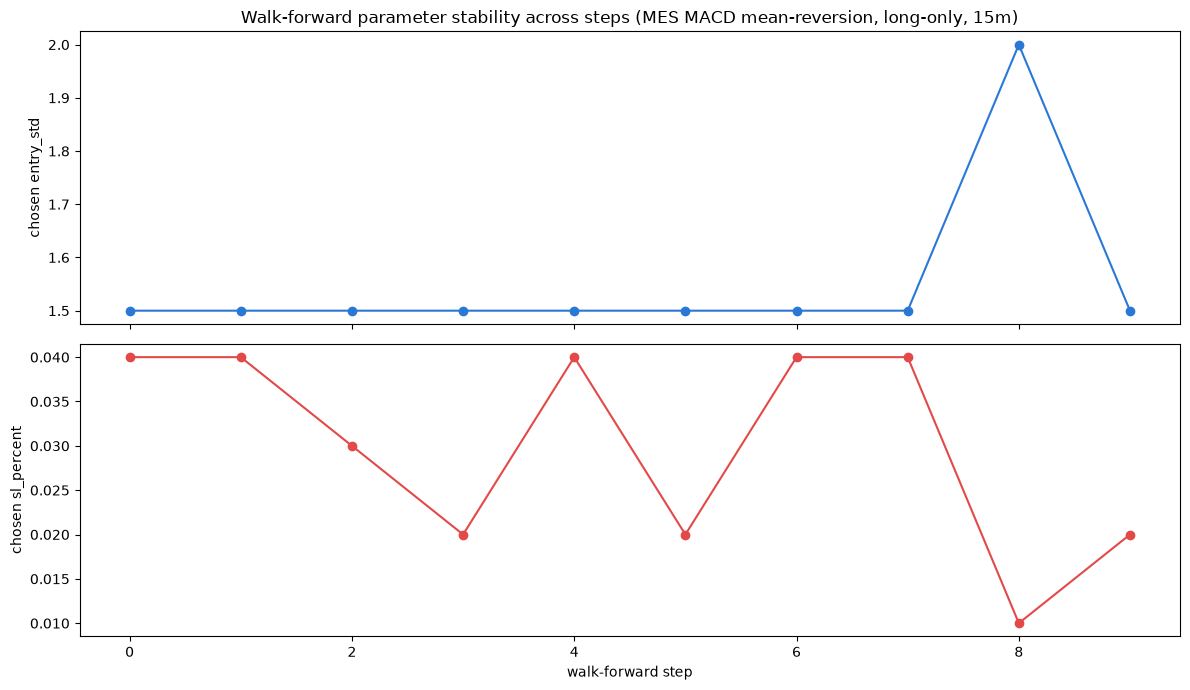

entry_std: unique values chosen = [np.float64(1.5), np.float64(2.0)]
sl_percent: unique values chosen = [np.float64(0.01), np.float64(0.02), np.float64(0.03), np.float64(0.04)]


In [11]:
fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
axes[0].plot(wf_results["step"], wf_results["chosen_entry_std"], marker="o", color="#2a78d6")
axes[0].set_ylabel("chosen entry_std")
axes[0].set_title("Walk-forward parameter stability across steps (MES MACD mean-reversion, long-only, 15m)")
axes[1].plot(wf_results["step"], wf_results["chosen_sl_percent"], marker="o", color="#e34948")
axes[1].set_ylabel("chosen sl_percent")
axes[1].set_xlabel("walk-forward step")
fig.tight_layout()
plt.show()

print(f"entry_std: unique values chosen = {sorted(wf_results['chosen_entry_std'].unique())}")
print(f"sl_percent: unique values chosen = {sorted(wf_results['chosen_sl_percent'].unique())}")


### The real track record: concatenated out-of-sample trades


In [12]:
wf_trade_sharpe, wf_trade_sharpe_lb, wf_n = trade_sharpe_lb(wf_oos_trades)
wf_wins = sum(1 for t in wf_oos_trades if t.pnl > 0)
wf_win_rate = (wf_wins / wf_n * 100) if wf_n else float("nan")
wf_total_pnl_percent = sum(t.pnl for t in wf_oos_trades) * 100

print(f"Concatenated OOS trades across all {len(wf_steps)} steps: {wf_n}")
print(f"OOS win rate: {wf_win_rate:.2f}%")
print(f"OOS trade_sharpe: {wf_trade_sharpe:.4f}")
print(f"OOS trade_sharpe_lb: {wf_trade_sharpe_lb:.4f}")
print(f"OOS sum of trade pnl (frictionless, %): {wf_total_pnl_percent:.2f}%")


Concatenated OOS trades across all 10 steps: 376
OOS win rate: 74.47%
OOS trade_sharpe: 0.0377
OOS trade_sharpe_lb: -0.0472
OOS sum of trade pnl (frictionless, %): 24.00%


## Walk-forward conclusion

**Negative -- the promising holdout does not survive, joining MES
SuperTrend, MES Keltner, and MES Bollinger-squeeze breakout in the "looked
good on one split, didn't confirm" bucket.**

| metric | value |
|---|---|
| OOS trades | 376 |
| OOS win rate | 74.5% |
| OOS `trade_sharpe` (point estimate) | +0.038 |
| OOS `trade_sharpe_lb` | **-0.0472** |
| OOS sum of trade pnl (frictionless) | +24.0% |

7 of 10 steps had a positive OOS net return -- a majority -- but the three
negative steps were sharp (step 1: -16.3%, `dollar_profit_factor` 0.62;
step 7: -9.3%, 0.61), enough to pull the pooled lower bound negative despite
the high win rate (74.5%, consistent with this being a mean-reversion
construction) and a positive point-estimate Sharpe.

**Parameter selection wandered on `sl_percent`**: `entry_std` was highly
stable (1.5 chosen in 9 of 10 steps), but `sl_percent` touched all four grid
values (0.01, 0.02, 0.03, 0.04) with no dominant choice -- a real instability
signal per this pipeline's own walk-forward criterion (`OPTIMIZATION_
RESEARCH_PLAN.md` Section 5.2), separate from and consistent with the
negative lower bound.

**Bottom line**: the single 75/25 holdout's TRAIN `trade_sharpe_lb=+0.0549`
was, like every other "promising single-split, failed walk-forward" result
in this pipeline, a fit to that particular training window rather than a
stable property of MES MACD mean-reversion long-only on 15-minute bars.
Combined with 30m's borderline (TRAIN lower bound essentially zero, not
walk-forwarded) and 1h's outright weak result, **MACD mean-reversion does
not clear this pipeline's bar for a validated edge on MES at any interval
tested.** MNQ is the natural next check, given this program's consistent
pattern of MNQ out-performing MES regardless of whether the MES version
confirms.